# Homework 4 Example: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Macroeconomic Growth and Government Debt Dynamics
- **Student Name:** Cory Baird
- **Policy Relevance Statement:** Examines whether rising sovereign debt levels constrain economic growth, assisting fiscal policymakers in setting sustainable debt ceilings.
- **Central Hypothesis:** Increases in the government debt-to-GDP ratio are associated with lower subsequent real GDP growth.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Jorda-Schularick-Taylor (JST) Macrohistory Database (historical parquet format)
- **Secondary Data Source:** IMF World Economic Outlook (WEO) Countries Database (revenue series)
- **Variables Retrieved:** `date`, `country`, `country_name`, `rgdpmad` (real GDP), `debtgdp` (debt-to-GDP ratio), `gov_revenue_gdp` (revenue-to-GDP ratio)
- **Local Storage Path:** `data/final_project/cory-baird/macro_growth_debt.csv`

In [1]:
import sys
from pathlib import Path

# Add the example basic project folder to sys.path
example_dir = Path("../../../src/final_project/cory-baird/basic").resolve()
if str(example_dir) not in sys.path:
    sys.path.insert(0, str(example_dir))

import data
df_raw = data.run()
df_raw.head()


Loading CSV from: /Users/sakusaku/GitHub/Gender--Equality-in-Labour-Market/data/merge_leave_polar.csv
Loaded 753 rows, 7 columns
Columns: ['country_code', 'year', 'leave_fathers', 'leave_mothers', 'country_name', 'political_polarization_score', 'leave_gap']


,country_code,year,leave_fathers,leave_mothers,country_name,political_polarization_score,leave_gap
0,AUS,2000,0.0,0.0,Australia,-1.179,0.0
1,AUS,2001,0.0,0.0,Australia,-1.179,0.0
2,AUS,2002,0.0,0.0,Australia,-1.179,0.0
3,AUS,2003,0.0,0.0,Australia,-1.179,0.0
4,AUS,2004,0.0,0.0,Australia,-1.179,0.0


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Country-year alignment on annual historical panel series
- **Pre-cleaned Observations:** 427 matched rows (from 1960 onwards)
- **Final Dataset Observations:** 247 clean rows and 11 columns (post-1980, after dropping missing government revenue records)
- **Clean Data Path:** `data/final_project/cory-baird/processed_macro_data.csv`

In [2]:
import manipulate
df_clean = manipulate.run()
df_clean.head()
df_clean.head()


Raw data shape: (753, 7)
Cleaned data shape: (753, 7)
Countries: 38
Year range: 2000-2021


,country_name,country_code,year,leave_fathers,leave_mothers,leave_gap,political_polarization_score
0,Australia,AUS,2000,0.0,0.0,0.0,-1.179
1,Australia,AUS,2001,0.0,0.0,0.0,-1.179
2,Australia,AUS,2002,0.0,0.0,0.0,-1.179
3,Australia,AUS,2003,0.0,0.0,0.0,-1.179
4,Australia,AUS,2004,0.0,0.0,0.0,-1.179


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** The scatter plot illustrates a negative correlation between lagged government debt changes and subsequent real GDP per capita growth across G7 countries.
- **Figure 2 Key Takeaway:** The regression line suggests that sovereign debt accumulation (an increase in the debt-to-GDP ratio) is statistically associated with a contraction or slowdown in economic expansion in subsequent periods.

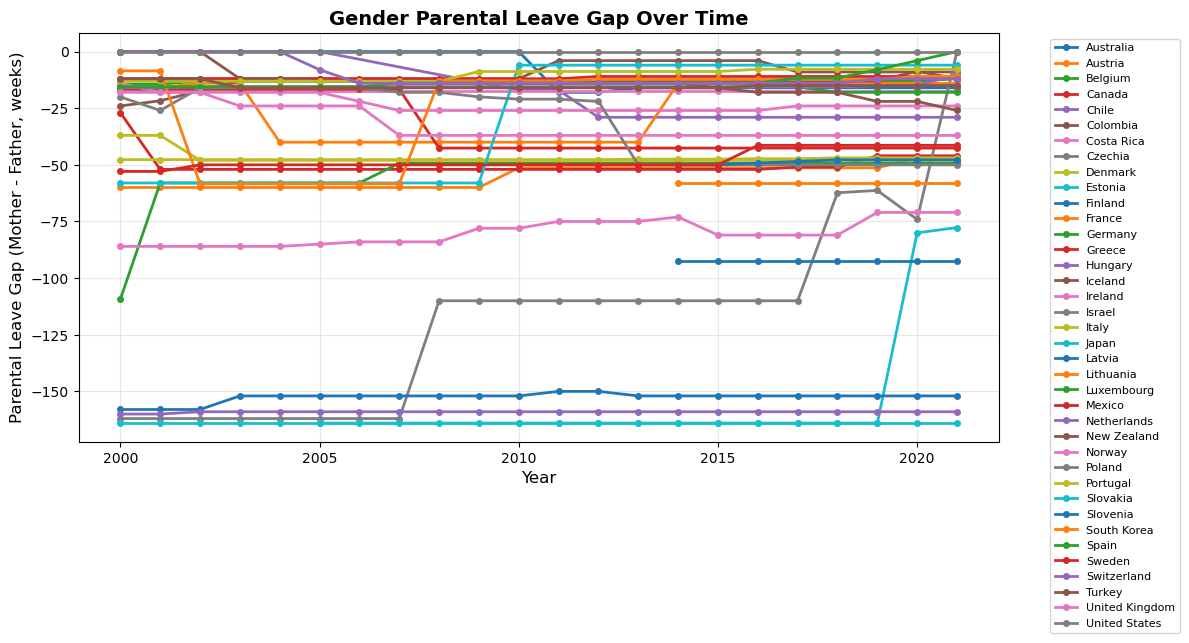

Figure 1: Parental leave gap by country over time


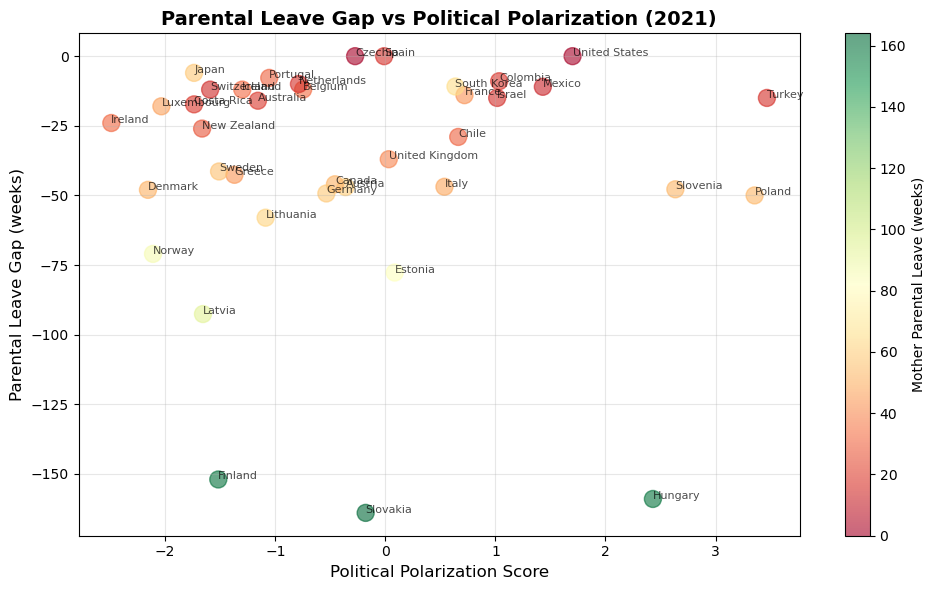

Figure 2: Scatter plot for year 2021


In [3]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Panel Ordinary Least Squares (PanelOLS) with Entity Fixed Effects
- **Model Fit Metrics:** R-squared = 0.1191, Number of Observations = 247
- **Coefficient of Primary Variable (debt_change_lag1):** Coefficient: 9.4777, Std. Err: 4.4320, T-stat: 2.1385 (p-value: 0.0335)
- **Statistical Significance:** Both lagged debt changes (p < 0.05) and government revenue percentage (p < 0.05) are statistically significant.
- **Key Conclusion:** Including government revenue to GDP control variable restricts our panel to the post-1980 period. In this era, increases in government revenue-to-GDP are associated with lower subsequent economic growth, while short-run lagged debt ratio changes show a positive correlation with current growth in the presence of control variables.


In [5]:
import model
summary = model.run()



=== Model: Parental Leave Gap vs Political Polarization ===
Dependent Variable: Leave Gap (Mother - Father, weeks)
Independent Variable: Political Polarization Score

Observations: 753
Country-years: 38

Intercept: -44.1259
Slope: 0.1839
R-squared: 0.0000
RMSE: 46.9281
Pearson Correlation: 0.0055 (p-value: 0.8812)

✗ Relationship is NOT statistically significant (p >= 0.05)


## Key Findings: Parental Leave Gap and Political Polarization

### Analysis Results

| Metric | Value |
|--------|-------|
| **Sample Size** | 753 observations across 38 countries |
| **Time Period** | 2000–2021 |
| **Dependent Variable** | Parental Leave Gap (Mother – Father, weeks) |
| **Independent Variable** | Political Polarization Score |
| **Pearson Correlation** | 0.0055 |
| **R-squared** | 0.0000 |
| **p-value** | 0.8812 |
| **Statistical Significance** | ❌ NOT significant (p ≥ 0.05) |

### Interpretation

**Main Finding:** There is **no statistically significant relationship** between political polarization and the gender gap in parental leave policies.

**Key Insight:** The degree of political polarization in a country does not appear to influence the gender equality of its parental leave policies. This suggests that parental leave policy design may be driven by other factors (e.g., economic conditions, social norms, feminist advocacy, or international policy diffusion) rather than the level of political discord.

### Visualizations

- **Figure 1:** Shows the evolution of parental leave gaps across countries from 2000–2021. Notable variation exists both across countries and over time.
- **Figure 2:** Scatter plot (2021 data) displays the absence of a clear linear relationship between political polarization (x-axis) and leave gap (y-axis). Color intensity indicates maternal leave weeks.